## MULTICLASS CLASSIFICATION

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelBinarizer

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

from sklearn.datasets import load_digits


#PART 1 — Data Loading & Exploration

#Load dataset
digits=load_digits()

X=digits.data #type:ignore
y=digits.target #type:ignore

In [2]:
# Basic info
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Unique classes:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

# Pixel stats
print("Min pixel:", np.min(X))
print("Max pixel:", np.max(X))

Shape of X: (1797, 64)
Shape of y: (1797,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10
Min pixel: 0.0
Max pixel: 16.0


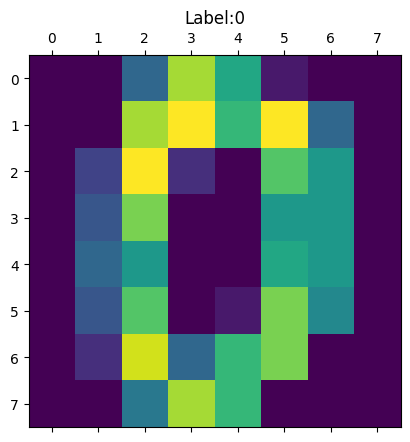

In [3]:
# SHow one Image
plt.matshow(digits.images[0]) #type:ignore
plt.title(f"Label:{y[0]}")
plt.show()

In [4]:
#Split
X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.2, random_state=42
)

In [5]:
#Scale
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [6]:
# Logistic Regression (OvR)
log_reg=LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [7]:
# SVM (OvO)
svm=SVC(kernel="rbf", probability=True)
svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [8]:
# Random Forest
rf=RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
#Predictions
y_pred_log=log_reg.predict(X_test_scaled)
y_pred_svm=svm.predict(X_test_scaled)

#Accuracy
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Accuracy: 0.9722222222222222
SVM Accuracy: 0.9805555555555555


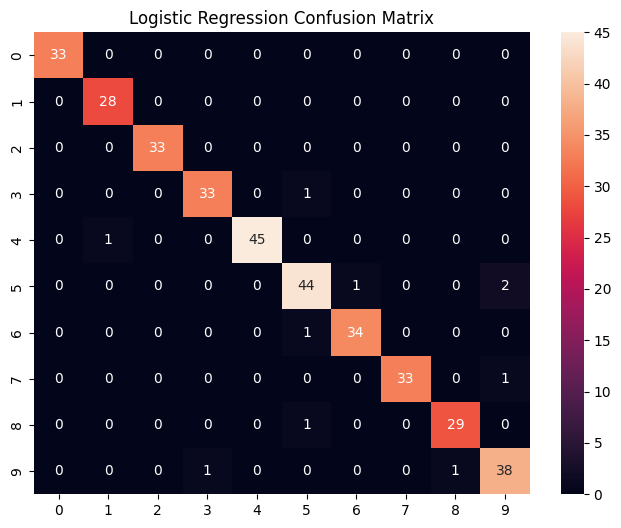

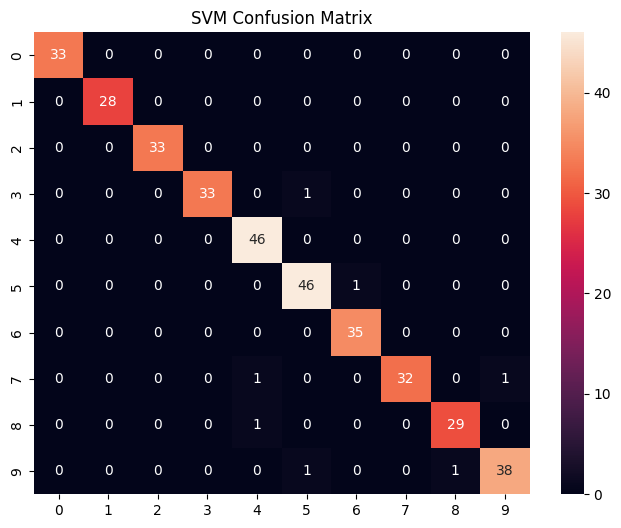

Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      0.98      0.99        46
           5       0.94      0.94      0.94        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.93      0.95      0.94        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

SVM:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00       

In [10]:
#Confusion Matrix
cm_log=confusion_matrix(y_test, y_pred_log)
cm_svm=confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8,6))
sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(cm_svm, annot=True, fmt="d")
plt.title("SVM Confusion Matrix")
plt.show()

# Classification Report
print("Logistic Regression:\n", classification_report(y_test, y_pred_log))
print("SVM:\n", classification_report(y_test, y_pred_svm))

In [11]:

# PART 5 — Advanced Metrics

#Precision

# Logistic
print("Logistic Macro Precision:", precision_score(y_test, y_pred_log, average='macro'))
print("Logistic Weighted Precision:", precision_score(y_test, y_pred_log, average='weighted'))

# SVM
print("SVM Macro Precision:", precision_score(y_test, y_pred_svm, average='macro'))
print("SVM Weighted Precision:", precision_score(y_test, y_pred_svm, average='weighted'))


#f1-score

# Logistic
print("Logistic Macro f1-score:", f1_score(y_test, y_pred_log, average='macro'))
print("Logistic Weighted f1-score:", f1_score(y_test, y_pred_log, average='weighted'))

# SVM
print("SVM Macro f1-score:", f1_score(y_test, y_pred_svm, average='macro'))
print("SVM Weighted Precision:", f1_score(y_test, y_pred_svm, average='weighted'))

#Recall

# Logistic
print("Logistic Macro Recall", recall_score(y_test, y_pred_log, average='macro'))
print("Logistic Weighted Recall:", recall_score(y_test, y_pred_log, average='weighted'))

# SVM
print("SVM Macro Recall:", recall_score(y_test, y_pred_svm, average='macro'))
print("SVM Weighted Recall:", recall_score(y_test, y_pred_svm, average='weighted'))

Logistic Macro Precision: 0.9737200195827308
Logistic Weighted Precision: 0.9725212596953555
SVM Macro Precision: 0.9829914529914531
SVM Weighted Precision: 0.9809087132003798
Logistic Macro f1-score: 0.9739667047321123
Logistic Weighted f1-score: 0.9722963303758159
SVM Macro f1-score: 0.9816523529529648
SVM Weighted Precision: 0.9805204312897433
Logistic Macro Recall 0.9743702791014647
Logistic Weighted Recall: 0.9722222222222222
SVM Macro Recall: 0.9807154776804337
SVM Weighted Recall: 0.9805555555555555


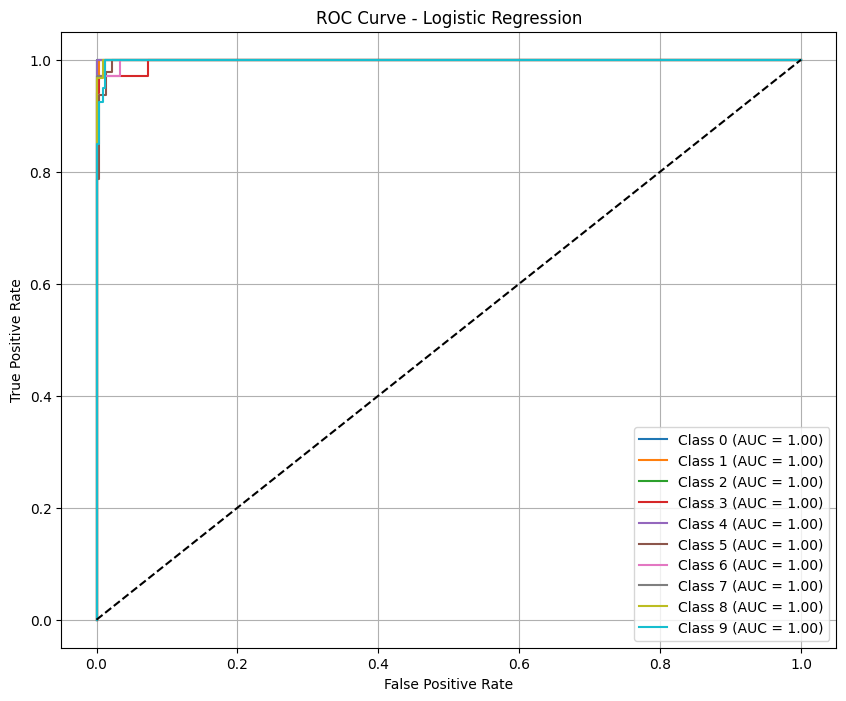

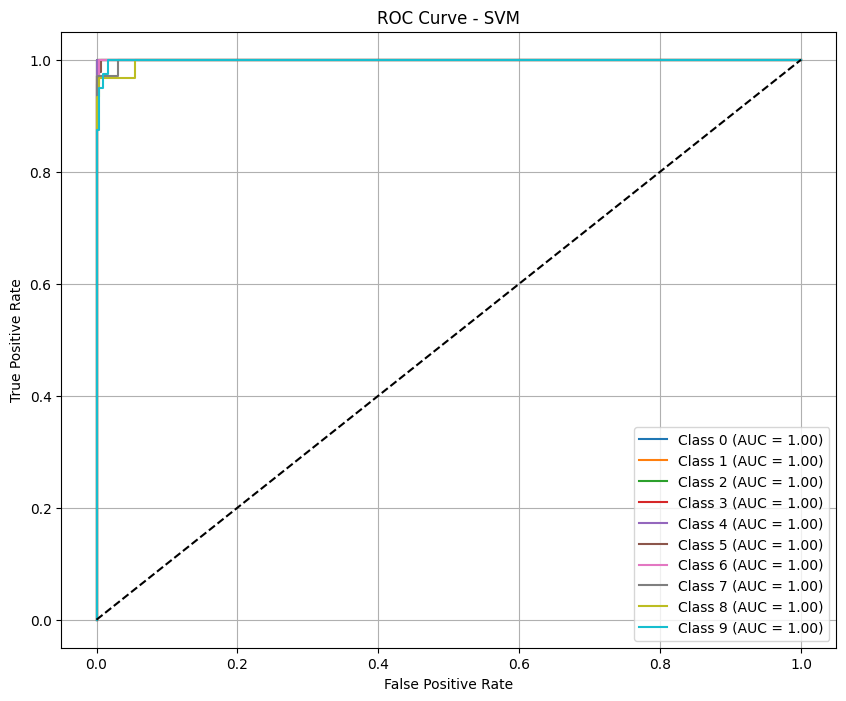

In [12]:
### ROC Curve (Multiclass - One-vs-Rest)
def plot_multiclass_roc(model, X_test, y_test, title):
    # Binarize labels
    lb = LabelBinarizer()
    y_test_bin = lb.fit_transform(y_test)

    # Get probabilities
    y_score = model.predict_proba(X_test)

    plt.figure(figsize=(10,8))

    for i in range(y_test_bin.shape[1]):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i]) #type:ignore
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    # Diagonal line
    plt.plot([0,1], [0,1], 'k--')

    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()
    

# Logistic Regression ROC
plot_multiclass_roc(log_reg, X_test_scaled, y_test, "ROC Curve - Logistic Regression")

# SVM ROC (make sure probability=True)
plot_multiclass_roc(svm, X_test_scaled, y_test, "ROC Curve - SVM")


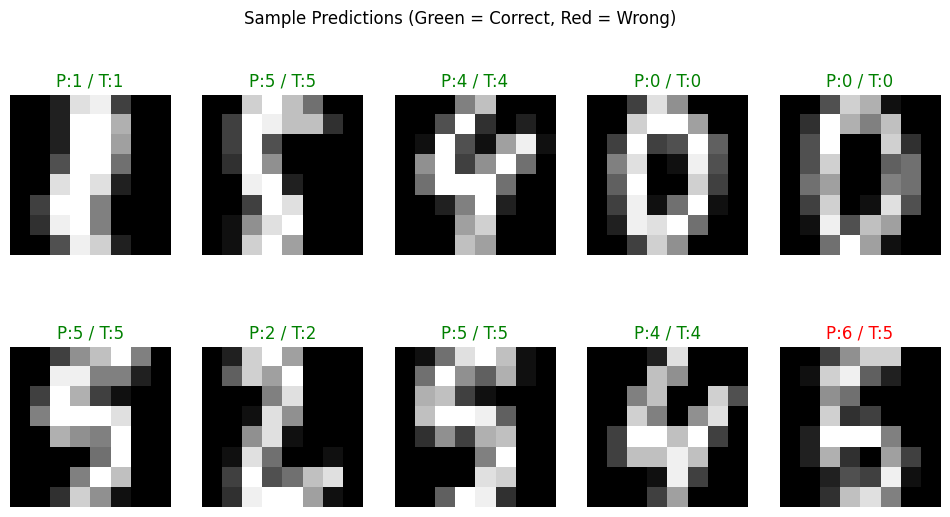

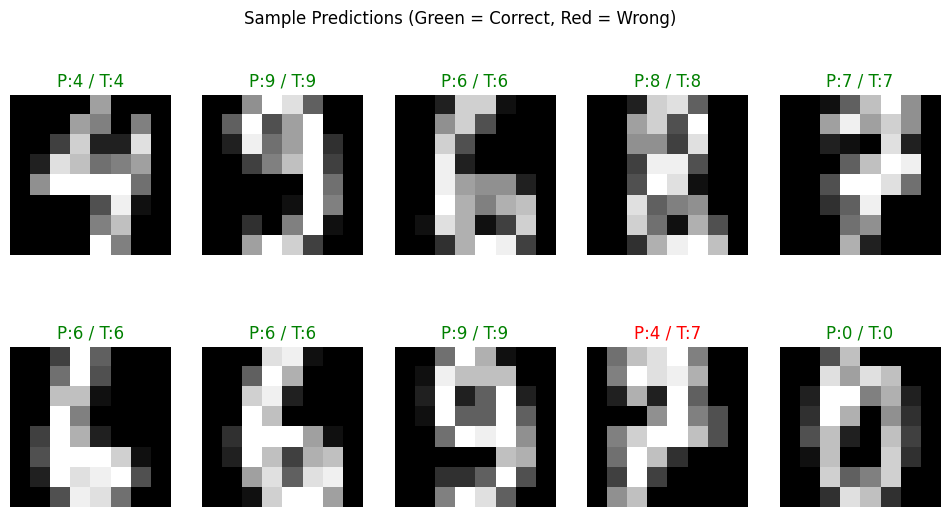

In [13]:
def  plot_sample_predictions(X_test, y_test, y_pred, n=10):
    indices=random.sample(range(len(X_test)), n)
    
    plt.figure(figsize=(12,6))

    for i, idx in enumerate(indices):
        plt.subplot(2, 5, i+1)

        # Reshape image (64 → 8x8)
        image = X_test[idx].reshape(8, 8)

        pred = y_pred[idx]
        true = y_test[idx]

        # Color for correctness
        color = 'green' if pred == true else 'red'

        plt.imshow(image, cmap='gray')
        plt.title(f"P:{pred} / T:{true}", color=color)

        # Border color
        ax = plt.gca()
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

        plt.axis('off')

    plt.suptitle("Sample Predictions (Green = Correct, Red = Wrong)")
    plt.show()


# Logistic Regression samples
plot_sample_predictions(X_test, y_test, y_pred_log)

# SVM samples
plot_sample_predictions(X_test, y_test, y_pred_svm)